# Audio Capture for Data Collection

In [ ]:
import sounddevice as sd
from scipy.io.wavfile import write as wav_write
import os

FS, DURATION, N_SAMPLES=16000, 1, 50
CLASSES=['clap', 'snap', 'tap', 'silence']
DATASET_DIR='dataset'

try:
    for label in CLASSES:
        saved_dir=os.path.join(DATASET_DIR, label)
        os.makedirs(saved_dir, exist_ok=True)
        print(f"\n--- {label.upper()} ---")
        input(f"Press ENTER when ready to record {N_SAMPLES} samples...")
        for i in range(N_SAMPLES):
            input(f"    [{i+1:02d}/{N_SAMPLES}] ENTER to record...")
            rec=sd.rec(int(DURATION*FS), samplerate=FS, channels=1, dtype="float32")
            sd.wait()
            wav_write(os.path.join(saved_dir, f'{i:03d}.wav'), FS, (rec*32767).astype('int16'))
            print(f"Saved {label}/{i:03d}.wav")
except ImportError:
    print("Run locally then upload dataset/")

Saved clap/000.wav
Saved clap/001.wav
Saved clap/002.wav
Saved clap/003.wav
Saved clap/004.wav
Saved clap/005.wav
Saved clap/006.wav
Saved clap/007.wav
Saved clap/008.wav
Saved clap/009.wav
Saved clap/010.wav
Saved clap/011.wav
Saved clap/012.wav
Saved clap/013.wav
Saved clap/014.wav
Saved clap/015.wav
Saved clap/016.wav
Saved clap/017.wav
Saved clap/018.wav
Saved clap/019.wav
Saved clap/020.wav
Saved clap/021.wav
Saved clap/022.wav
Saved clap/023.wav
Saved clap/024.wav
Saved clap/025.wav
Saved clap/026.wav
Saved clap/027.wav
Saved clap/028.wav
Saved clap/029.wav
Saved clap/030.wav
Saved clap/031.wav
Saved clap/032.wav
Saved clap/033.wav
Saved clap/034.wav
Saved clap/035.wav
Saved clap/036.wav
Saved clap/037.wav
Saved clap/038.wav
Saved clap/039.wav
Saved clap/040.wav
Saved clap/041.wav
Saved clap/042.wav
Saved clap/043.wav
Saved clap/044.wav
Saved clap/045.wav
Saved clap/046.wav
Saved clap/047.wav
Saved clap/048.wav
Saved clap/049.wav
Saved snap/000.wav
Saved snap/001.wav
Saved snap/0

Code to analyze the .wav output, to verify the variation

--- Audio Stats ---
Sampling Rate: 16000 Hz
Duration: 1.00 seconds
Peak Amplitude: 1.0855
RMS Energy: 0.0887


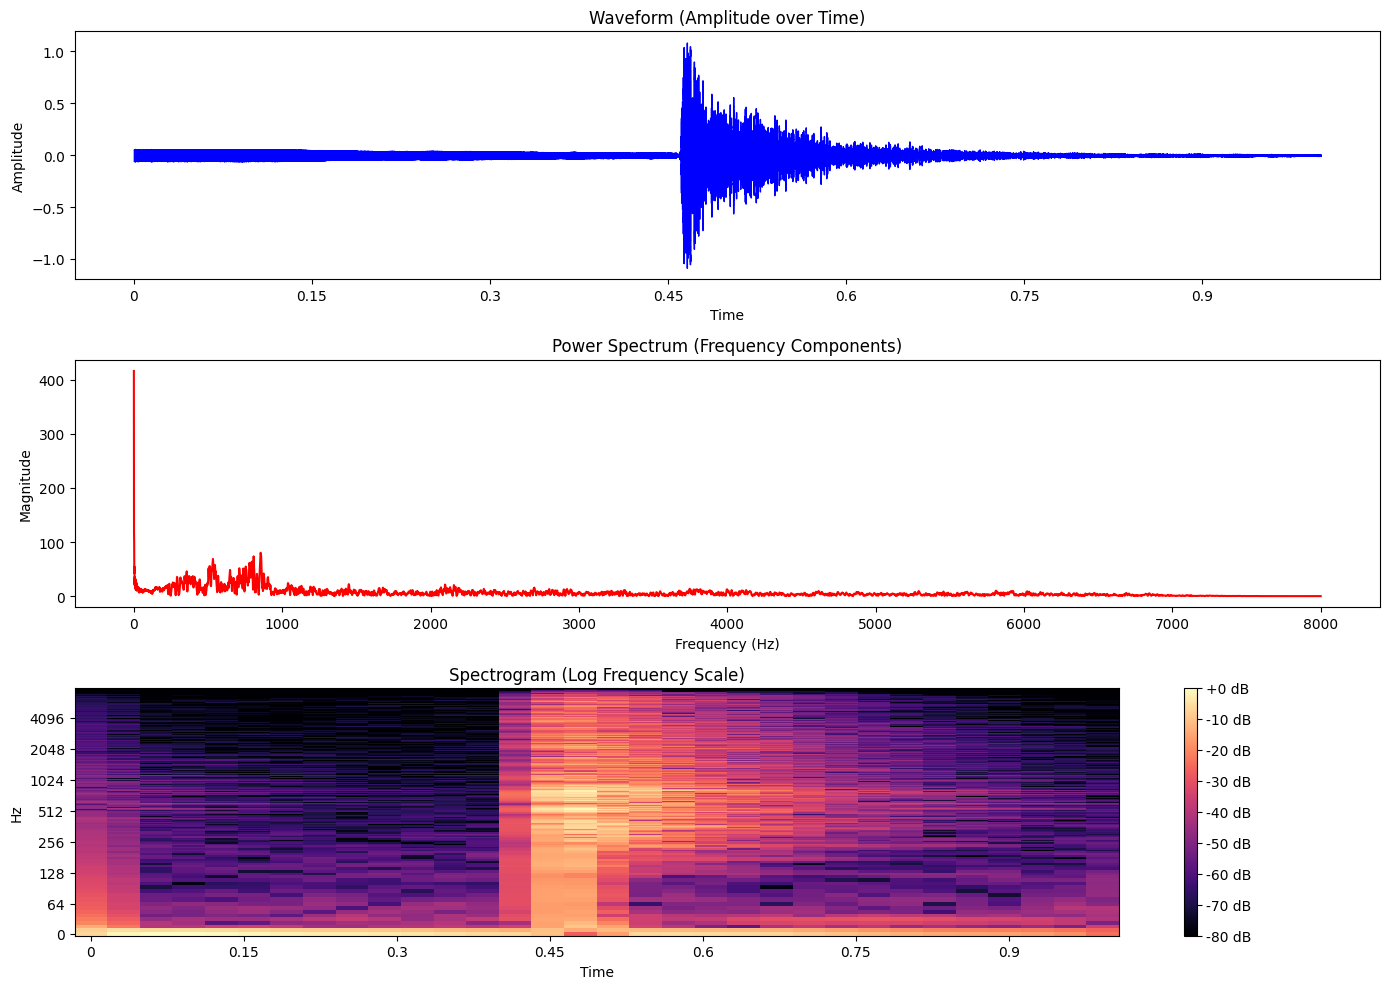

Analysis saved as dataset/clap/1_analysis.png


<Figure size 640x480 with 0 Axes>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy.io import wavfile

def analyze_wav(file_path):
    # 1. Load the file
    # sr=None preserves the original sampling rate
    y, sr = librosa.load(file_path, sr=None)
    duration = librosa.get_duration(y=y, sr=sr)
    
    print(f"--- Audio Stats ---")
    print(f"Sampling Rate: {sr} Hz")
    print(f"Duration: {duration:.2f} seconds")
    print(f"Peak Amplitude: {np.max(np.abs(y)):.4f}")
    print(f"RMS Energy: {np.sqrt(np.mean(y**2)):.4f}")

    plt.figure(figsize=(14, 10))

    # 2. Waveform Plot (Time Domain)
    plt.subplot(3, 1, 1)
    librosa.display.waveshow(y, sr=sr, color='blue')
    plt.title('Waveform (Amplitude over Time)')
    plt.ylabel('Amplitude')

    # 3. Power Spectrum (Frequency Domain - FFT)
    plt.subplot(3, 1, 2)
    fft = np.fft.fft(y)
    magnitude = np.abs(fft)
    frequency = np.linspace(0, sr, len(magnitude))
    # Plot only the positive half of the spectrum
    left_frequency = frequency[:int(len(frequency)/2)]
    left_magnitude = magnitude[:int(len(magnitude)/2)]
    plt.plot(left_frequency, left_magnitude, color='red')
    plt.title('Power Spectrum (Frequency Components)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')

    # 4. Spectrogram (Time-Frequency Domain)
    plt.subplot(3, 1, 3)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Spectrogram (Log Frequency Scale)')

    plt.tight_layout()
    plt.show()
    save_path = file_path.replace('.wav', '_analysis.png')
    plt.savefig(save_path)
    print(f"Analysis saved as {save_path}")

# Run the analysis
analyze_wav('dataset/clap/1.wav')

# MFCC Feature Extraciton

Use of CMSIS DSP, to emulate that in Python, we will have no Slaney normalisation using norm=None, the arm_vlogf32 function and the scaling will be handled via funciton power_to_df in librosa library

In [10]:
import librosa


SR=16000
N_FFT=512
HOP_LENGTH=256
N_MELS=26
N_MFCC=13
FMIN=0
FMAX=8000
FIXED_FRAMES=32
CLASSES=['clap', 'snap', 'tap', 'silence']
DATASET_DIR='dataset'

def extract_mfcc(path):
    y, _=librosa.load(path, sr=SR, mono=True, dtype='float32')
    y/=(np.max(np.abs(y))+1e-9)
    mel=librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS, fmin=FMIN, fmax=FMAX, window="hamming", norm=None)
    log_mel=librosa.power_to_db(mel, ref=np.max)
    mfccs=librosa.feature.mfcc(S=log_mel, n_mfcc=N_MFCC, dct_type=2)
    if mfccs.shape[1]<FIXED_FRAMES:
        mfccs=np.pad(mfccs, ((0,0),(0,FIXED_FRAMES-mfccs.shape[1])))
    return mfccs[:, :FIXED_FRAMES]

X, y_labels=[], []
for ci, label in enumerate(CLASSES):
    d=os.path.join(DATASET_DIR, label)
    if not os.path.isdir(d): 
        print(f"Missing {d}")
        continue
    files=[f for f in os.listdir(d) if f.endswith('.wav')]
    print(f'{label:10s}: {len(files)} files')
    for f in files:
        try:
            features=extract_mfcc(os.path.join(d, f))
            X.append(features)
            y_labels.append(ci)
            
        except Exception as e:
            print(f"    Skip {f}: {e}")
X=np.array(X)[..., np.newaxis] #Extra dimension for NN
y=np.array(y_labels)
print(f"\nX={X.shape} y={y.shape}")
print('Class counts:', dict(zip(CLASSES, np.bincount(y))))

clap      : 100 files
snap      : 100 files
tap       : 99 files
silence   : 100 files

X=(399, 13, 32, 1) y=(399,)
Class counts: {'clap': np.int64(100), 'snap': np.int64(100), 'tap': np.int64(99), 'silence': np.int64(100)}


# Training

In [13]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io.wavfile import write as wav_write
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models

X_train, X_temp, y_train, y_temp=train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test=train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

MEAN=float(X_train.mean())
STD=float(X_train.std())+1e-9
X_train=(X_train-MEAN)/STD
X_val=(X_val-MEAN)/STD
X_test=(X_test-MEAN)/STD

print(f"Train={X_train.shape} Val={X_val.shape} Test={X_test.shape}")
print(f'MFCC_MEAN   {MEAN:.6f}')
print(f'MFCC_STD    {STD:.6f}')


I0000 00:00:1776682307.077458  287564 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776682307.135190  287564 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776682308.569047  287564 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Train=(279, 13, 32, 1) Val=(60, 13, 32, 1) Test=(60, 13, 32, 1)
MFCC_MEAN   -12.178165
MFCC_STD    65.034790


In [17]:
def build_model():
    return models.Sequential([
        layers.Conv2D(8, (3,3), activation="relu", padding="same", input_shape=X_train.shape[1:]),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Conv2D(16, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(32,activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(len(CLASSES), activation="softmax")
    ], name="SoundClassifier")

model=build_model()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "SoundClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 13, 32, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 13, 32, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 16, 8)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 6, 16, 8)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 16, 16)      │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 6, 16, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 3, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │        12,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,796 (53.89 KB)

 Trainable params: 13,748 (53.70 KB)

 Non-trainable params: 48 (192.00 B)

In [18]:
callbacks=[
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
]

history=model.fit(X_train, y_train, epochs=300, batch_size=8, validation_data=(X_val, y_val), callbacks=callbacks, verbose=1)

Epoch 1/300


I0000 00:00:1776682650.754428  549759 service.cc:153] XLA service 0x760fd0038b60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776682650.754453  549759 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776682650.826803  549759 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776682651.170903  549759 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776682651.285927  549759 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2876__.43


27/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2348 - loss: 3.1141  

I0000 00:00:1776682659.587042  549759 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1776682660.246003  549759 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2876__.43


35/35 ━━━━━━━━━━━━━━━━━━━━ 23s 303ms/step - accuracy: 0.3369 - loss: 2.0952 - val_accuracy: 0.2667 - val_loss: 1.3703 - learning_rate: 0.0010
Epoch 2/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4659 - loss: 1.2710 - val_accuracy: 0.2500 - val_loss: 1.3768 - learning_rate: 0.0010
Epoch 3/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5448 - loss: 1.0507 - val_accuracy: 0.2500 - val_loss: 1.5248 - learning_rate: 0.0010
Epoch 4/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6667 - loss: 0.8311 - val_accuracy: 0.2500 - val_loss: 1.7361 - learning_rate: 0.0010
Epoch 5/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6810 - loss: 0.7685 - val_accuracy: 0.2500 - val_loss: 1.9605 - learning_rate: 0.0010
Epoch 6/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6810 - loss: 0.7722 - val_accuracy: 0.2500 - val_loss: 1.9757 - learning_rate: 0.0010
Epoch 7/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6953 - loss: 0.6778 - val_accurac

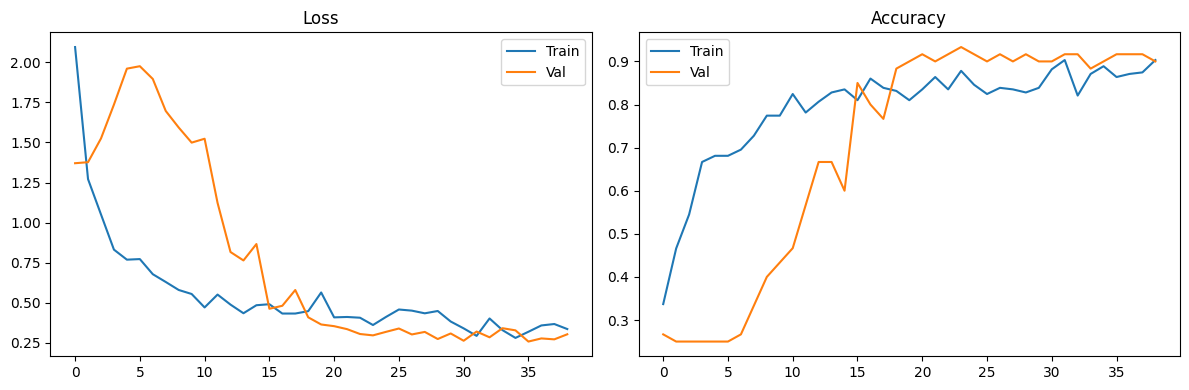

In [19]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12,4))
ax1.plot(history.history['loss'],label='Train'); ax1.plot(history.history['val_loss'],label='Val')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(history.history['accuracy'],label='Train'); ax2.plot(history.history['val_accuracy'],label='Val')
ax2.set_title('Accuracy'); ax2.legend()
plt.tight_layout(); plt.savefig('training_curves.png',dpi=150); plt.show()

Test Accuracy: 86.67%  |  Loss: 0.5241

              precision    recall  f1-score   support

        clap       1.00      0.73      0.85        15
        snap       0.86      0.80      0.83        15
         tap       0.78      0.93      0.85        15
     silence       0.88      1.00      0.94        15

    accuracy                           0.87        60
   macro avg       0.88      0.87      0.86        60
weighted avg       0.88      0.87      0.86        60



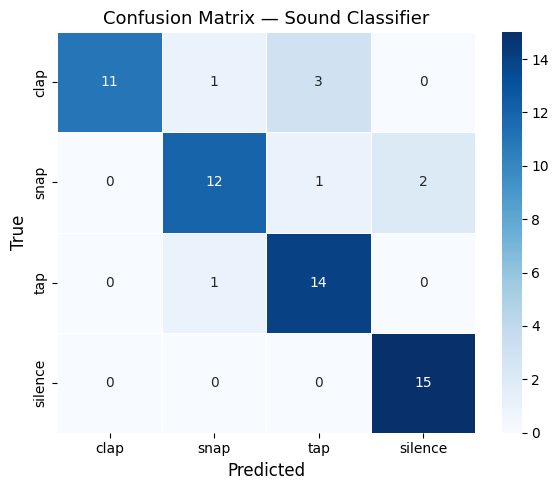

💾 confusion_matrix.png saved — include in README


In [21]:
loss,acc = model.evaluate(X_test,y_test,verbose=0)
print(f'Test Accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}')
y_pred = np.argmax(model.predict(X_test,verbose=0),axis=1)
print('\n'+classification_report(y_test,y_pred,target_names=CLASSES))
cm = confusion_matrix(y_test,y_pred)
fig,ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=CLASSES,yticklabels=CLASSES,linewidths=0.5,ax=ax)
ax.set_xlabel('Predicted',fontsize=12); ax.set_ylabel('True',fontsize=12)
ax.set_title('Confusion Matrix — Sound Classifier',fontsize=13)
plt.tight_layout(); plt.savefig('confusion_matrix.png',dpi=150); plt.show()
print('💾 confusion_matrix.png saved — include in README')

# Export for Deployment

In [22]:
converter=tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model=converter.convert()
with open('sound_model.tflite', "wb") as f: 
    f.write(tflite_model)
size_kb=len(tflite_model)/1024
print(f"Size: {size_kb:.1f} KB")
print('Fits in Nano 33 BLE flash' if size_kb<=512 else "Not fit, consider quantization")

INFO:tensorflow:Assets written to: /tmp/tmp68pcje4w/assets


INFO:tensorflow:Assets written to: /tmp/tmp68pcje4w/assets


Saved artifact at '/tmp/tmp68pcje4w'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13, 32, 1), dtype=tf.float32, name='keras_tensor_13')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  129825923302800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129825923303952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129825923303568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129825923303184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129825923302992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129825923303760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129825923305296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129825923306256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129825923305872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129825923305680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1298259233051

W0000 00:00:1776682924.936490  287564 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1776682924.936537  287564 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1776682924.937179  287564 reader.cc:83] Reading SavedModel from: /tmp/tmp68pcje4w
I0000 00:00:1776682924.939033  287564 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1776682924.939047  287564 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp68pcje4w
I0000 00:00:1776682924.952717  287564 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1776682924.954696  287564 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1776682925.023977  287564 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp68pcje4w
I0000 00:00:1776682925.041638  287564 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 104475 microseconds.


The simulation has been done on linux on which works command: xxd -i [.tflite] > [.h header]. Remember in any case to move the header into the deployment folder. If that is not the case run the code below:

In [23]:
import os

def bin_to_header(model_path, header_path, array_name="g_model"):
    with open(model_path, 'rb') as f:
        content=f.read()
    with open(header_path, 'w') as f:
        f.write(f'#include <stdint.h>')
        f.write(f"const unsigned char {array_name}[] __attribute__((aligned(16)))={{\n ")
        for i, byte in enumerate(content):
            f.write(f'0x{byte:02x}, ')
            if (i+1)%12==0:
                f.write("\n ")
        f.write(f"\n}};\,\,")
        f.write(f"const unsigned int {array_name}_len={len(content)};\n")
        
bin_to_header("sound_model.tflite", "sound_model.h")

<>:13: SyntaxWarning: invalid escape sequence '\,'
<>:13: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_287564/2229917032.py:13: SyntaxWarning: invalid escape sequence '\,'
  f.write(f"\n}};\,\,")


In [24]:
!mv sound_model.h deployment/